# Life Expectancy Data – Exploratory Data Analysis



## Task 1 – Load & Inspect

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

df = pd.read_csv("Life_Expectancy_Data.csv")
df.columns = df.columns.str.strip()

print("First 5 rows:")
display(df.head())
print("\nColumn dtypes:")
print(df.dtypes.to_string())
print(f"\nShape: {df.shape}")

First 5 rows:


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5



Column dtypes:
Country                             object
Year                                 int64
Status                              object
Life expectancy                    float64
Adult Mortality                    float64
infant deaths                        int64
Alcohol                            float64
percentage expenditure             float64
Hepatitis B                        float64
Measles                              int64
BMI                                float64
under-five deaths                    int64
Polio                              float64
Total expenditure                  float64
Diphtheria                         float64
HIV/AIDS                           float64
GDP                                float64
Population                         float64
thinness  1-19 years               float64
thinness 5-9 years                 float64
Income composition of resources    float64
Schooling                          float64

Shape: (2938, 22)


## Task 2 – Null Value Analysis

In [2]:
null_count = df.isnull().sum()
null_pct   = (null_count / df.shape[0]) * 100
null_df    = pd.DataFrame({"null_count": null_count, "null_pct": null_pct.round(4)})
print("Null counts and percentages per column:")
display(null_df)

high_null_cols = null_df[null_df["null_pct"] > 20].index.tolist()
print(f"\nColumns exceeding 20% null rate: {high_null_cols}")

# Median imputation for columns < 20% null
for col in df.select_dtypes(include=[np.number]).columns:
    if null_df.loc[col, "null_pct"] <= 20:
        df[col] = df[col].fillna(df[col].median())

print("\nNull counts after median imputation (columns < 20%):")
print(df.isnull().sum().to_string())

Null counts and percentages per column:


,null_count,null_pct
Country,0,0.0000
Year,0,0.0000
Status,0,0.0000
Life expectancy,10,0.3404
Adult Mortality,10,0.3404
infant deaths,0,0.0000
Alcohol,194,6.6031
percentage expenditure,0,0.0000
Hepatitis B,553,18.8223
Measles,0,0.0000



Columns exceeding 20% null rate: ['Population']

Null counts after median imputation (columns < 20%):
Country                              0
Year                                 0
Status                               0
Life expectancy                      0
Adult Mortality                      0
infant deaths                        0
Alcohol                              0
percentage expenditure               0
Hepatitis B                          0
Measles                              0
BMI                                  0
under-five deaths                    0
Polio                                0
Total expenditure                    0
Diphtheria                           0
HIV/AIDS                             0
GDP                                  0
Population                         652
thinness  1-19 years                 0
thinness 5-9 years                   0
Income composition of resources      0
Schooling                            0


### Additional Graph: Missing Value Percentage by Column

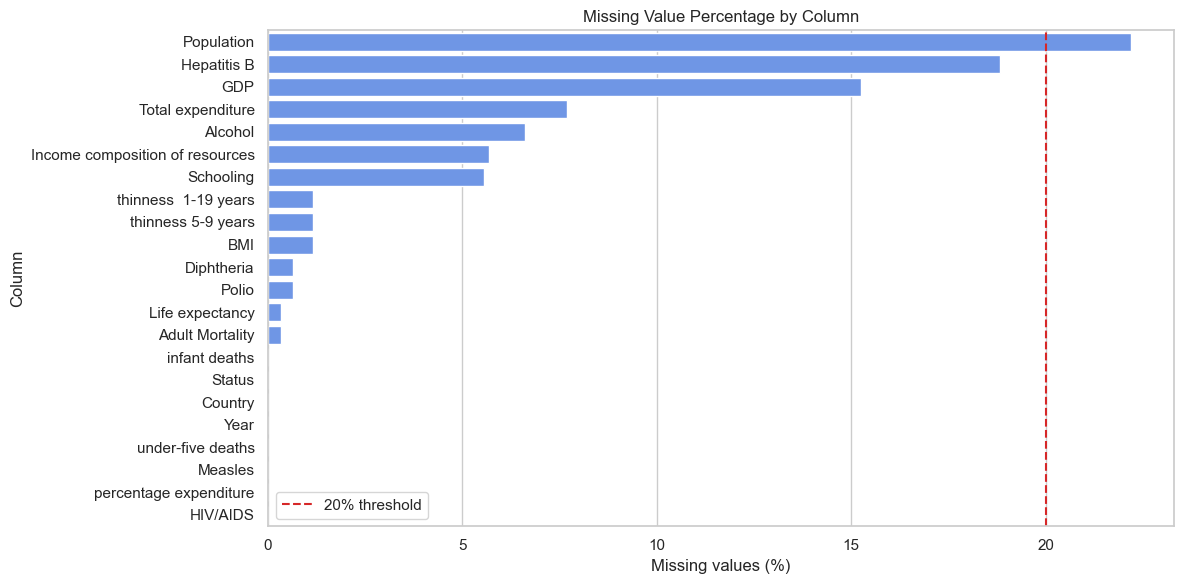

In [3]:
# Additional Graph: Missing-value percentage by column before imputation.
missing_plot_df = null_df.sort_values("null_pct", ascending=False).reset_index().rename(columns={"index": "column"})
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=missing_plot_df, x="null_pct", y="column", ax=ax, color="#5B8FF9")
ax.axvline(20, color="#D62728", linestyle="--", linewidth=1.5, label="20% threshold")
ax.set_title("Missing Value Percentage by Column")
ax.set_xlabel("Missing values (%)")
ax.set_ylabel("Column")
ax.legend()
plt.tight_layout()
plt.show()

## Task 3 – Duplicate Detection & Removal

In [4]:
n_dupes = df.duplicated().sum()
print(f"Duplicate rows found: {n_dupes}")

null_pct_before = (df.isnull().sum() / df.shape[0]) * 100
df = df.drop_duplicates()
null_pct_after  = (df.isnull().sum() / df.shape[0]) * 100

print(f"Rows removed: {n_dupes}")
change = (null_pct_after - null_pct_before).round(4)
changed = change[change != 0]
if len(changed):
    print("\nColumns with changed null %:"); print(changed)
else:
    print("\nNo change in null percentages after duplicate removal.")

Duplicate rows found: 0
Rows removed: 0

No change in null percentages after duplicate removal.


## Task 4 – Data Type Correction

In [5]:
mem_before = df.memory_usage(deep=True).sum()

print("No numeric column was incorrectly loaded as object.")
print("Country and Status are repetitive string columns, so they are converted to category.")

df["Year"] = pd.to_numeric(df["Year"], errors="coerce").astype("Int64")
df["Status"] = df["Status"].astype("category")
df["Country"] = df["Country"].astype("category")

mem_after = df.memory_usage(deep=True).sum()
print(f"Memory before: {mem_before:,} bytes")
print(f"Memory after : {mem_after:,} bytes")
print(f"Memory saved : {mem_before - mem_after:,} bytes")
print("\nUpdated dtypes:")
print(df.dtypes.to_string())

No numeric column was incorrectly loaded as object.
Country and Status are repetitive string columns, so they are converted to category.
Memory before: 817,001 bytes
Memory after : 497,776 bytes
Memory saved : 319,225 bytes

Updated dtypes:
Country                            category
Year                                  Int64
Status                             category
Life expectancy                     float64
Adult Mortality                     float64
infant deaths                         int64
Alcohol                             float64
percentage expenditure              float64
Hepatitis B                         float64
Measles                               int64
BMI                                 float64
under-five deaths                     int64
Polio                               float64
Total expenditure                   float64
Diphtheria                          float64
HIV/AIDS                            float64
GDP                                 float64
Population 

## Task 5 – Descriptive Statistics & Skewness

In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("Descriptive statistics:")
display(df[numeric_cols].describe().T.round(3))

skew_series = df[numeric_cols].skew().sort_values(key=abs, ascending=False)
print("\nSkewness (sorted by |skew|):")
display(skew_series.round(4).rename("skewness"))

most_skewed_col = skew_series.index[0]
most_skewed_val = skew_series.iloc[0]
print(f"\nMost skewed column: '{most_skewed_col}' (skewness = {most_skewed_val:.4f})")

Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
Year,2938.0,2007.51872,4.613841,2000.0,2004.0,2008.0,2012.0,2015.0
Life expectancy,2938.0,69.234717,9.509115,36.3,63.2,72.1,75.6,89.0
Adult Mortality,2938.0,164.725664,124.086215,1.0,74.0,144.0,227.0,723.0
infant deaths,2938.0,30.303948,117.926501,0.0,0.0,3.0,22.0,1800.0
Alcohol,2938.0,4.546875,3.921946,0.01,1.0925,3.755,7.39,17.87
percentage expenditure,2938.0,738.251295,1987.914858,0.0,4.685343,64.912906,441.534144,19479.91161
Hepatitis B,2938.0,83.022124,22.996984,1.0,82.0,92.0,96.0,99.0
Measles,2938.0,2419.59224,11467.272489,0.0,0.0,17.0,360.25,212183.0
BMI,2938.0,38.381178,19.935375,1.0,19.4,43.5,56.1,87.3
under-five deaths,2938.0,42.035739,160.445548,0.0,0.0,4.0,28.0,2500.0



Skewness (sorted by |skew|):


Population                         15.9162
infant deaths                        9.787
under-five deaths                   9.4951
Measles                             9.4413
HIV/AIDS                            5.3961
percentage expenditure              4.6521
GDP                                 3.5438
Hepatitis B                        -2.2817
Polio                              -2.1089
Diphtheria                         -2.0836
thinness 5-9 years                  1.7957
thinness  1-19 years                1.7295
Income composition of resources    -1.2125
Adult Mortality                     1.1779
Total expenditure                   0.6611
Alcohol                             0.6496
Life expectancy                    -0.6424
Schooling                          -0.6351
BMI                                -0.2292
Year                               -0.0064
Name: skewness, dtype: Float64


Most skewed column: 'Population' (skewness = 15.9162)


### Additional Graph: Top 10 Absolute Skewness Values

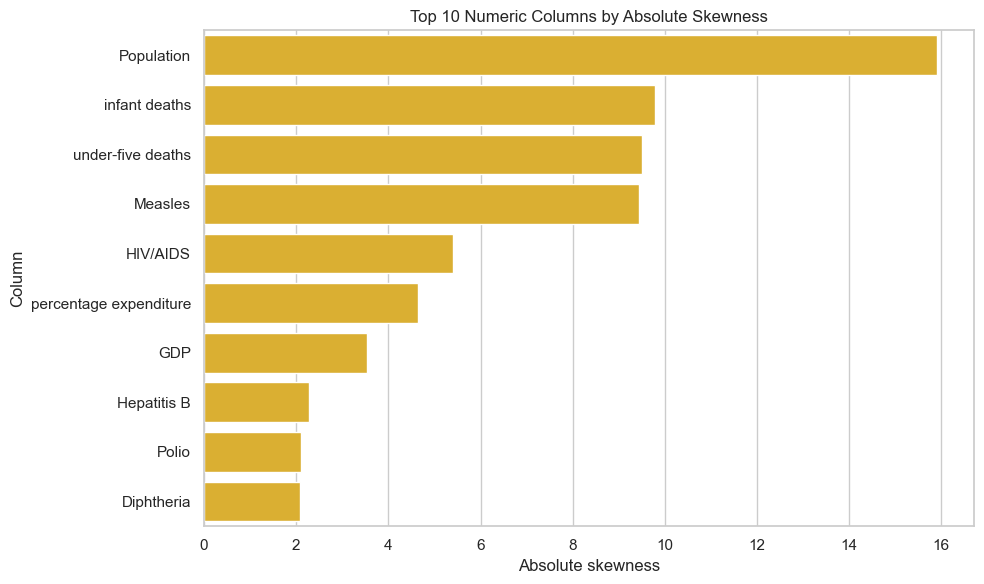

In [7]:
# Additional Graph: Top 10 absolute skewness values.
skew_plot_df = skew_series.abs().sort_values(ascending=False).head(10).reset_index()
skew_plot_df.columns = ["column", "absolute_skewness"]
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=skew_plot_df, x="absolute_skewness", y="column", ax=ax, color="#F6BD16")
ax.set_title("Top 10 Numeric Columns by Absolute Skewness")
ax.set_xlabel("Absolute skewness")
ax.set_ylabel("Column")
plt.tight_layout()
plt.show()

## Task 6 – Outlier Detection with IQR

In [8]:
iqr_cols = ["GDP", "Population"]
for col in iqr_cols:
    q1  = df[col].quantile(0.25)
    q3  = df[col].quantile(0.75)
    iqr = q3 - q1
    lo  = q1 - 1.5 * iqr
    hi  = q3 + 1.5 * iqr
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    print(f"{col}:")
    print(f"  Q1 = {q1:.2f}  |  Q3 = {q3:.2f}  |  IQR = {iqr:.2f}")
    print(f"  Lower bound = {lo:.2f}  |  Upper bound = {hi:.2f}")
    print(f"  Outlier rows: {n_out}\n")

GDP:
  Q1 = 580.49  |  Q3 = 4779.41  |  IQR = 4198.92
  Lower bound = -5717.89  |  Upper bound = 11077.78
  Outlier rows: 445

Population:
  Q1 = 195793.25  |  Q3 = 7420359.00  |  IQR = 7224565.75
  Lower bound = -10641055.38  |  Upper bound = 18257207.62
  Outlier rows: 294



## Task 7 – Visualizations
### 7a – Line Plot: Global Average Life Expectancy by Year

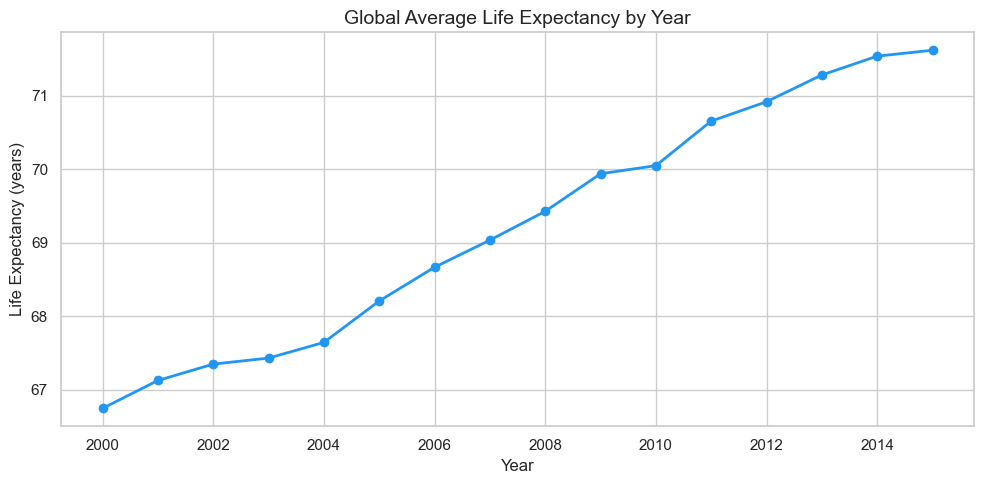

In [9]:
avg_le = df.groupby("Year")["Life expectancy"].mean().sort_index()
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(avg_le.index, avg_le.values, marker="o", linewidth=2, color="#2196F3")
ax.set_title("Global Average Life Expectancy by Year", fontsize=14)
ax.set_xlabel("Year")
ax.set_ylabel("Life Expectancy (years)")
plt.tight_layout()
plt.show()

### 7b – Bar Chart: Mean Life Expectancy by Development Status

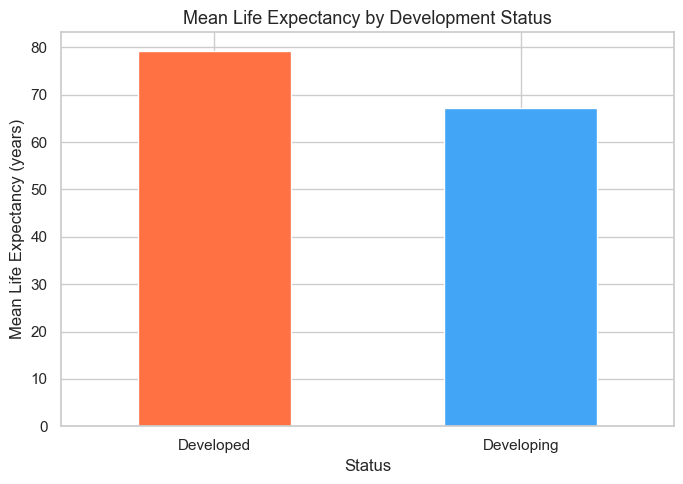

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
df.groupby("Status")["Life expectancy"].mean().plot.bar(
    ax=ax, color=["#FF7043", "#42A5F5"])
ax.set_title("Mean Life Expectancy by Development Status", fontsize=13)
ax.set_xlabel("Status")
ax.set_ylabel("Mean Life Expectancy (years)")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

### 7c – Histogram: Most Skewed Column

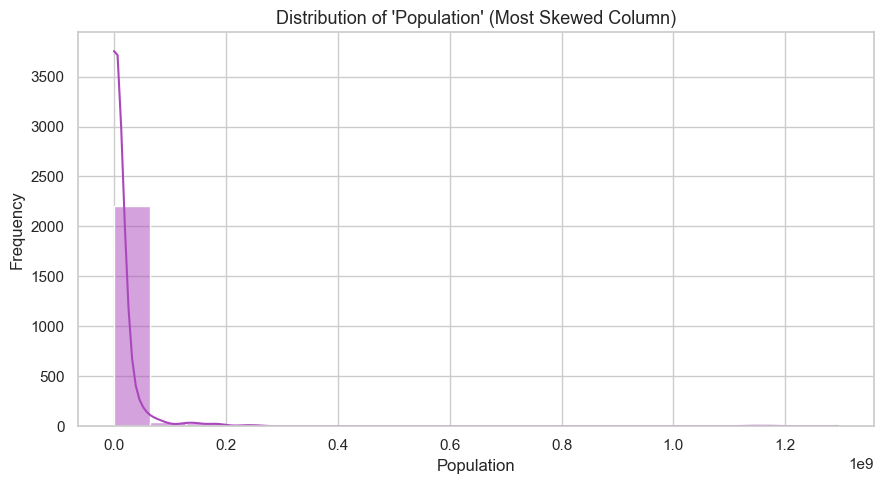

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(df[most_skewed_col].dropna(), bins=20, ax=ax, kde=True, color="#AB47BC")
ax.set_title(f"Distribution of '{most_skewed_col}' (Most Skewed Column)", fontsize=13)
ax.set_xlabel(most_skewed_col)
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

### 7d – Scatter Plot: GDP vs Life Expectancy

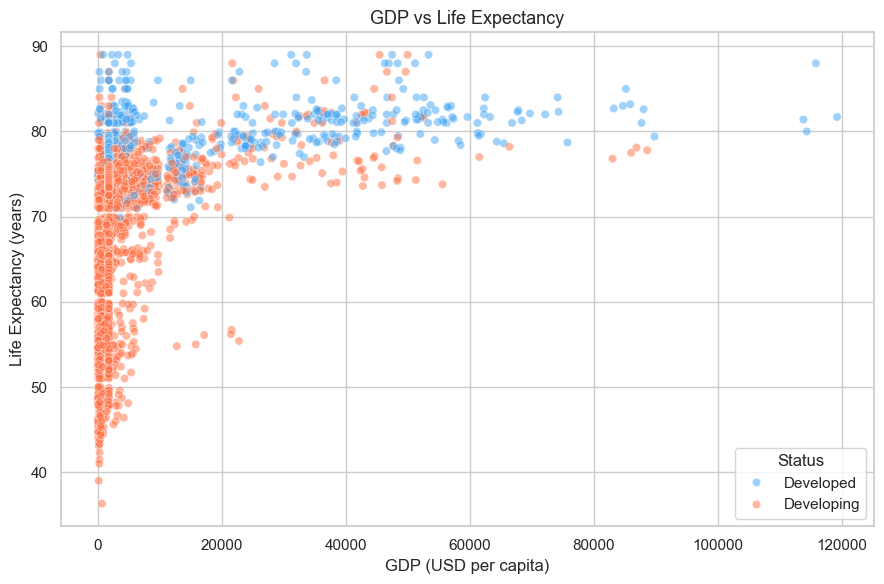

In [12]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=df, x="GDP", y="Life expectancy", hue="Status",
                alpha=0.5, ax=ax, palette={"Developing": "#FF7043", "Developed": "#42A5F5"})
ax.set_title("GDP vs Life Expectancy", fontsize=13)
ax.set_xlabel("GDP (USD per capita)")
ax.set_ylabel("Life Expectancy (years)")
plt.tight_layout()
plt.show()

### 7e – Box Plot: Life Expectancy by Development Status

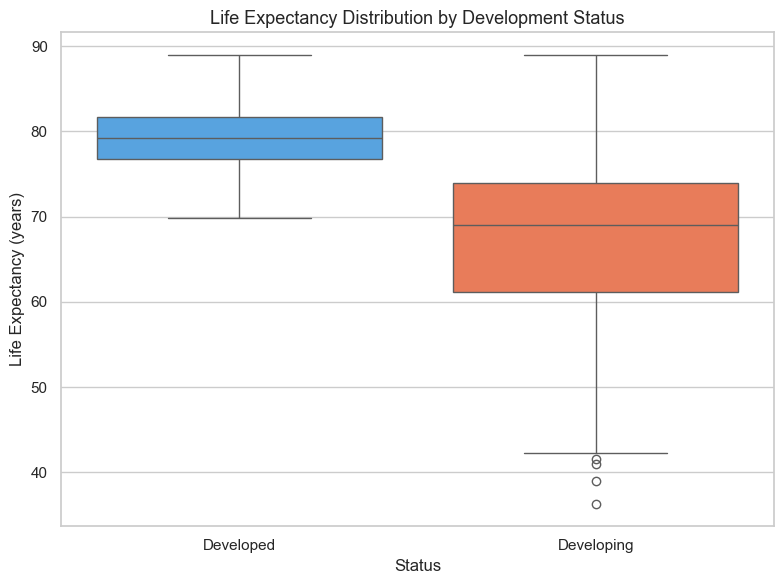

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=df, x="Status", y="Life expectancy", ax=ax,
            palette={"Developing": "#FF7043", "Developed": "#42A5F5"})
ax.set_title("Life Expectancy Distribution by Development Status", fontsize=13)
ax.set_xlabel("Status")
ax.set_ylabel("Life Expectancy (years)")
plt.tight_layout()
plt.show()

### Additional Graph: Violin Plot by Development Status

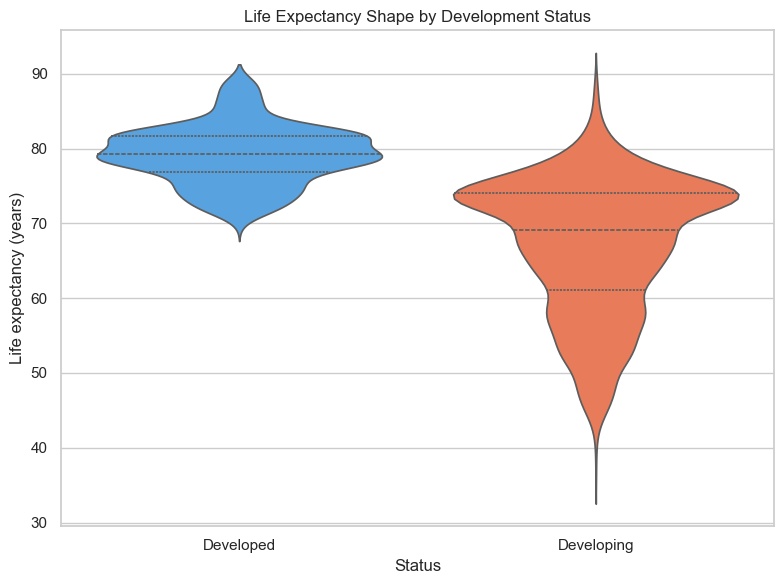

In [14]:
# Additional Graph: Violin plot of life expectancy by development status.
fig, ax = plt.subplots(figsize=(8, 6))
sns.violinplot(data=df, x="Status", y="Life expectancy", ax=ax, palette={"Developing": "#FF7043", "Developed": "#42A5F5"}, inner="quartile")
ax.set_title("Life Expectancy Shape by Development Status")
ax.set_xlabel("Status")
ax.set_ylabel("Life expectancy (years)")
plt.tight_layout()
plt.show()

## Task 8 – Correlation Heat Map (Pearson)

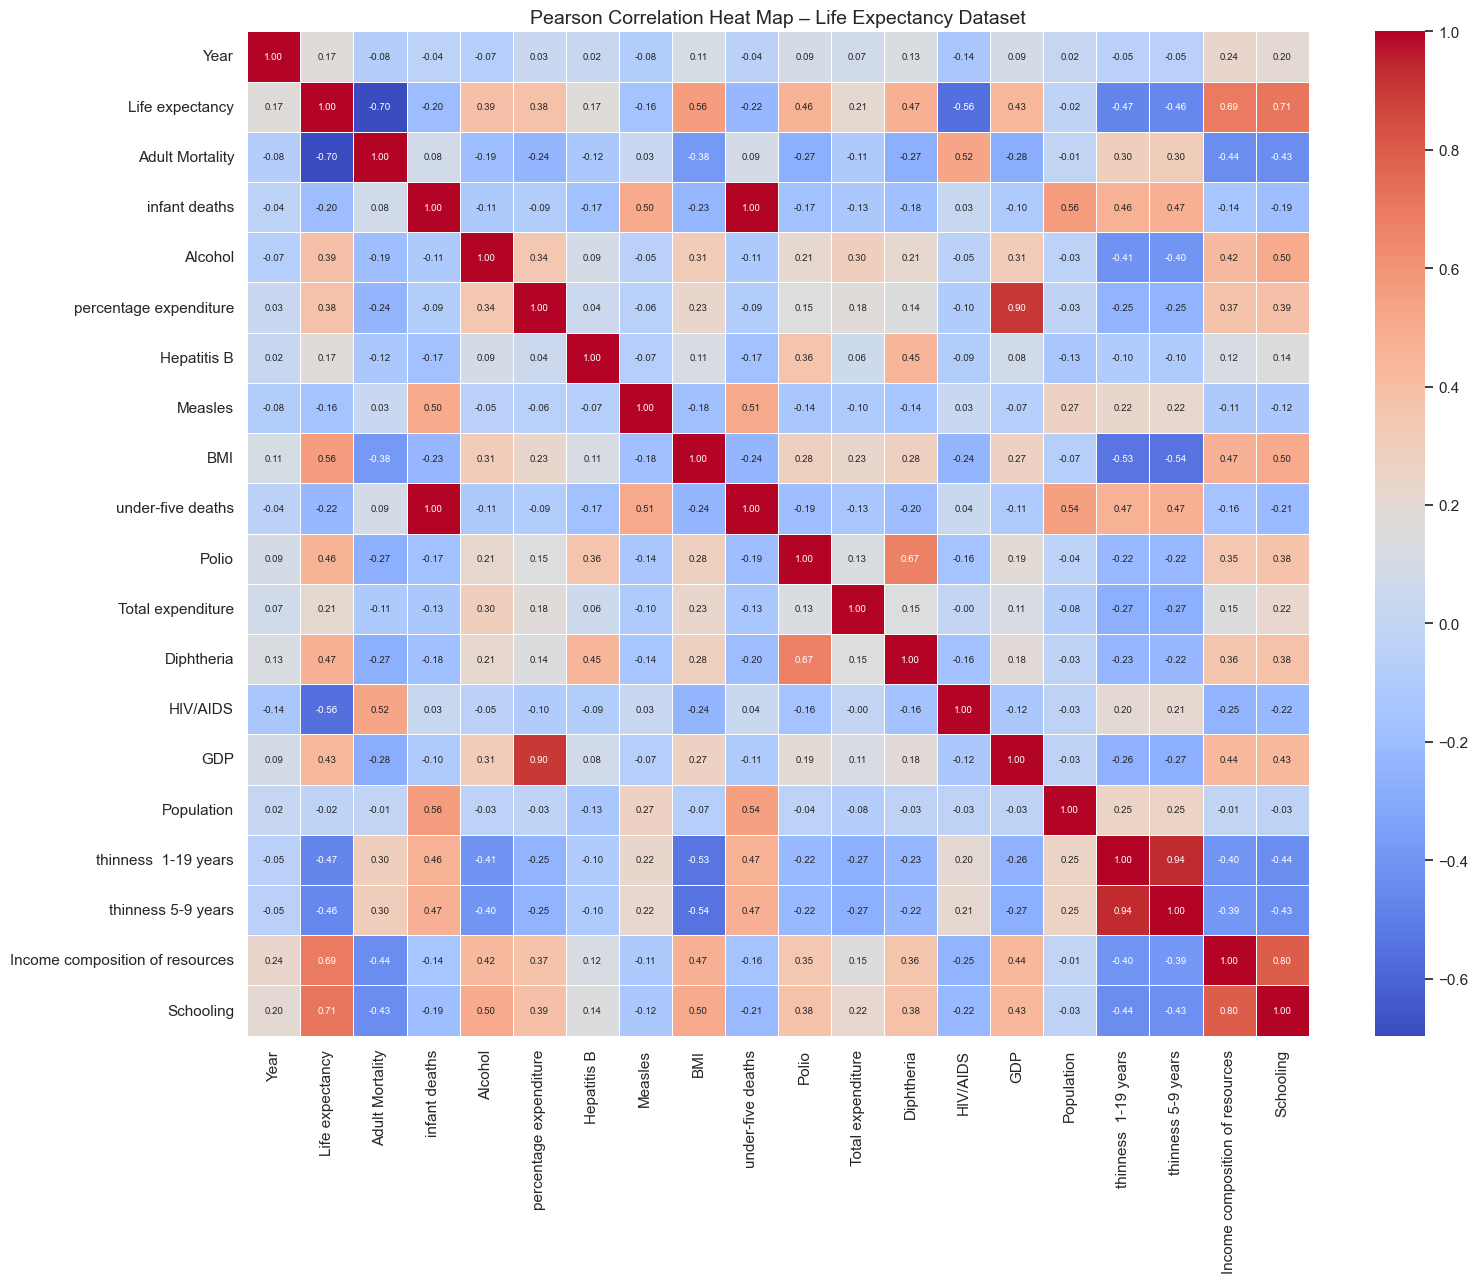

Highest |Pearson| correlation: 'infant deaths' ↔ 'under-five deaths' = 0.9966


In [15]:
corr_pearson = df[numeric_cols].corr(method="pearson")
fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(corr_pearson, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.4, ax=ax, annot_kws={"size": 7})
ax.set_title("Pearson Correlation Heat Map – Life Expectancy Dataset", fontsize=14)
plt.tight_layout()
plt.show()

corr_abs_vals = corr_pearson.abs().values.copy()
np.fill_diagonal(corr_abs_vals, 0)
corr_abs = pd.DataFrame(corr_abs_vals, index=corr_pearson.index, columns=corr_pearson.columns)
max_pair = np.unravel_index(corr_abs.values.argmax(), corr_abs.shape)
col_a, col_b = corr_abs.columns[max_pair[0]], corr_abs.columns[max_pair[1]]
print(f"Highest |Pearson| correlation: '{col_a}' ↔ '{col_b}' = {corr_pearson.loc[col_a, col_b]:.4f}")

## Task 9a – Imputation Strategy Comparison (Top-2 Skewed Columns)

In [16]:
top2_skewed = skew_series.head(2).index.tolist()
for col in top2_skewed:
    mean_val   = df[col].mean()
    median_val = df[col].median()
    skew_val   = df[col].skew()
    print(f"{col}  (skew = {skew_val:.4f})")
    print(f"  Mean   = {mean_val:.4f}")
    print(f"  Median = {median_val:.4f}\n")
    df[col] = df[col].fillna(median_val)

print("Null counts after final imputation:")
print(df[top2_skewed].isnull().sum().to_string())

Population  (skew = 15.9162)
  Mean   = 12753375.1201
  Median = 1386542.0000

infant deaths  (skew = 9.7870)
  Mean   = 30.3039
  Median = 3.0000

Null counts after final imputation:
Population       0
infant deaths    0


## Task 9b – Spearman vs Pearson Correlation

In [17]:
corr_spearman = df[numeric_cols].corr(method="spearman")

diff_vals = (corr_spearman - corr_pearson).abs().values.copy()
np.fill_diagonal(diff_vals, 0)
diff_abs = pd.DataFrame(diff_vals, index=corr_pearson.index, columns=corr_pearson.columns)

diff_flat = diff_abs.where(np.triu(np.ones(diff_abs.shape), k=1).astype(bool))
top3 = diff_flat.stack().sort_values(ascending=False).head(3)

print("Top-3 |Spearman − Pearson| differences:")
display(top3.rename("|Spearman − Pearson|"))

print("\nPearson Correlation Matrix:")
display(corr_pearson.round(3))

print("\nSpearman Correlation Matrix:")
display(corr_spearman.round(3))

print("\n|Spearman − Pearson| Difference Table:")
display(diff_abs.round(4))

Top-3 |Spearman − Pearson| differences:


under-five deaths  HIV/AIDS                           0.473759
infant deaths      HIV/AIDS                           0.461414
                   Income composition of resources    0.418977
Name: |Spearman − Pearson|, dtype: float64


Pearson Correlation Matrix:


,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
Year,1.000,0.171,-0.080,-0.037,-0.069,0.031,0.021,-0.082,0.108,-0.043,0.091,0.075,0.131,-0.140,0.091,0.017,-0.048,-0.051,0.237,0.204
Life expectancy,0.171,1.000,-0.696,-0.197,0.389,0.381,0.170,-0.158,0.557,-0.223,0.458,0.209,0.472,-0.557,0.430,-0.022,-0.468,-0.462,0.689,0.713
Adult Mortality,-0.080,-0.696,1.000,0.079,-0.190,-0.243,-0.123,0.031,-0.379,0.094,-0.270,-0.112,-0.270,0.524,-0.281,-0.014,0.296,0.302,-0.436,-0.433
infant deaths,-0.037,-0.197,0.079,1.000,-0.113,-0.086,-0.167,0.501,-0.227,0.997,-0.171,-0.126,-0.175,0.025,-0.103,0.557,0.465,0.470,-0.142,-0.191
Alcohol,-0.069,0.389,-0.190,-0.113,1.000,0.344,0.091,-0.050,0.313,-0.110,0.212,0.296,0.212,-0.046,0.313,-0.034,-0.413,-0.402,0.418,0.499
percentage expenditure,0.031,0.381,-0.243,-0.086,0.344,1.000,0.040,-0.057,0.227,-0.088,0.146,0.176,0.143,-0.098,0.902,-0.026,-0.250,-0.251,0.375,0.386
Hepatitis B,0.021,0.170,-0.123,-0.167,0.091,0.040,1.000,-0.073,0.112,-0.171,0.365,0.056,0.449,-0.085,0.077,-0.131,-0.098,-0.101,0.118,0.141
Measles,-0.082,-0.158,0.031,0.501,-0.050,-0.057,-0.073,1.000,-0.176,0.508,-0.137,-0.104,-0.142,0.031,-0.069,0.266,0.225,0.221,-0.111,-0.121
BMI,0.108,0.557,-0.379,-0.227,0.313,0.227,0.112,-0.176,1.000,-0.237,0.281,0.231,0.280,-0.243,0.274,-0.072,-0.532,-0.539,0.472,0.500
under-five deaths,-0.043,-0.223,0.094,0.997,-0.110,-0.088,-0.171,0.508,-0.237,1.000,-0.189,-0.128,-0.196,0.038,-0.106,0.544,0.467,0.471,-0.159,-0.206



Spearman Correlation Matrix:


,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
Year,1.000,0.157,-0.053,-0.052,-0.086,-0.050,0.086,-0.095,0.147,-0.052,0.108,0.072,0.131,-0.056,0.163,0.037,-0.040,-0.038,0.193,0.191
Life expectancy,0.157,1.000,-0.650,-0.599,0.424,0.427,0.298,-0.280,0.580,-0.617,0.531,0.283,0.541,-0.753,0.598,-0.072,-0.603,-0.613,0.829,0.778
Adult Mortality,-0.053,-0.650,1.000,0.391,-0.208,-0.297,-0.199,0.145,-0.390,0.404,-0.317,-0.171,-0.326,0.522,-0.360,0.085,0.384,0.399,-0.528,-0.477
infant deaths,-0.052,-0.599,0.391,1.000,-0.367,-0.361,-0.308,0.573,-0.477,0.993,-0.428,-0.214,-0.425,0.487,-0.467,0.386,0.448,0.462,-0.561,-0.579
Alcohol,-0.086,0.424,-0.208,-0.367,1.000,0.277,0.104,-0.195,0.309,-0.366,0.249,0.339,0.265,-0.188,0.377,-0.004,-0.450,-0.442,0.479,0.511
percentage expenditure,-0.050,0.427,-0.297,-0.361,0.277,1.000,0.096,-0.153,0.278,-0.362,0.209,0.147,0.222,-0.255,0.627,-0.049,-0.302,-0.303,0.465,0.451
Hepatitis B,0.086,0.298,-0.199,-0.308,0.104,0.096,1.000,-0.195,0.174,-0.305,0.701,0.043,0.717,-0.295,0.218,-0.086,-0.038,-0.053,0.300,0.299
Measles,-0.095,-0.280,0.145,0.573,-0.195,-0.153,-0.195,1.000,-0.276,0.574,-0.267,-0.185,-0.265,0.204,-0.203,0.264,0.307,0.321,-0.230,-0.278
BMI,0.147,0.580,-0.390,-0.477,0.309,0.278,0.174,-0.276,1.000,-0.488,0.324,0.256,0.334,-0.516,0.444,-0.050,-0.565,-0.575,0.591,0.584
under-five deaths,-0.052,-0.617,0.404,0.993,-0.366,-0.362,-0.305,0.574,-0.488,1.000,-0.432,-0.219,-0.428,0.512,-0.474,0.381,0.456,0.469,-0.572,-0.590



|Spearman − Pearson| Difference Table:


,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
Year,0.0000,0.0142,0.0267,0.0149,0.0168,0.0814,0.0647,0.0123,0.0382,0.0088,0.0171,0.0025,0.0001,0.0836,0.0711,0.0201,0.0081,0.0126,0.0436,0.0124
Life expectancy,0.0142,0.0000,0.0460,0.4021,0.0354,0.0459,0.1276,0.1227,0.0235,0.3938,0.0730,0.0745,0.0685,0.1960,0.1670,0.0502,0.1350,0.1506,0.1407,0.0647
Adult Mortality,0.0267,0.0460,0.0000,0.3124,0.0178,0.0543,0.0761,0.1142,0.0108,0.3098,0.0473,0.0588,0.0558,0.0017,0.0789,0.0991,0.0881,0.0970,0.0920,0.0434
infant deaths,0.0149,0.4021,0.3124,0.0000,0.2540,0.2749,0.1403,0.0718,0.2498,0.0034,0.2576,0.0875,0.2495,0.4614,0.3645,0.1705,0.0167,0.0082,0.4190,0.3878
Alcohol,0.0168,0.0354,0.0178,0.2540,0.0000,0.0676,0.0132,0.1452,0.0043,0.2562,0.0375,0.0429,0.0526,0.1417,0.0641,0.0306,0.0371,0.0402,0.0605,0.0118
percentage expenditure,0.0814,0.0459,0.0543,0.2749,0.0676,0.0000,0.0561,0.0963,0.0504,0.2742,0.0629,0.0281,0.0797,0.1572,0.2750,0.0237,0.0525,0.0520,0.0907,0.0650
Hepatitis B,0.0647,0.1276,0.0761,0.1403,0.0132,0.0561,0.0000,0.1222,0.0613,0.1346,0.3362,0.0130,0.2675,0.2095,0.1412,0.0448,0.0601,0.0472,0.1824,0.1574
Measles,0.0123,0.1227,0.1142,0.0718,0.1452,0.0963,0.1222,0.0000,0.1002,0.0663,0.1301,0.0810,0.1223,0.1734,0.1336,0.0023,0.0824,0.1001,0.1186,0.1574
BMI,0.0382,0.0235,0.0108,0.2498,0.0043,0.0504,0.0613,0.1002,0.0000,0.2510,0.0430,0.0253,0.0536,0.2725,0.1700,0.0224,0.0321,0.0355,0.1188,0.0839
under-five deaths,0.0088,0.3938,0.3098,0.0034,0.2562,0.2742,0.1346,0.0663,0.2510,0.0000,0.2433,0.0915,0.2322,0.4738,0.3681,0.1634,0.0107,0.0025,0.4127,0.3840


## Task 9c – Grouped Aggregation

In [18]:
cat_col = "Status"
num_col = "Life expectancy"
grouped = df.groupby(cat_col)[num_col].agg(["mean", "std", "count"])
display(grouped.round(3))

highest_mean_group = grouped["mean"].idxmax()
highest_std_group  = grouped["std"].idxmax()
mean_ratio = grouped["mean"].max() / grouped["mean"].min()
print(f"\nHighest-mean group : {highest_mean_group} (mean = {grouped.loc[highest_mean_group, 'mean']:.2f})")
print(f"Highest-std  group : {highest_std_group} (std = {grouped.loc[highest_std_group, 'std']:.2f})")
print(f"Ratio (max mean / min mean): {mean_ratio:.3f}")

,mean,std,count
Status,,,
Developed,79.198,3.931,512
Developing,67.132,8.993,2426



Highest-mean group : Developed (mean = 79.20)
Highest-std  group : Developing (std = 8.99)
Ratio (max mean / min mean): 1.180


## Task 10 – Save Cleaned Dataset

In [19]:
df.to_csv("cleaned_data.csv", index=False)
print(f"Saved: cleaned_data.csv  ({df.shape[0]} rows and {df.shape[1]} cols)")


Saved: cleaned_data.csv  (2938 rows and 22 cols)
